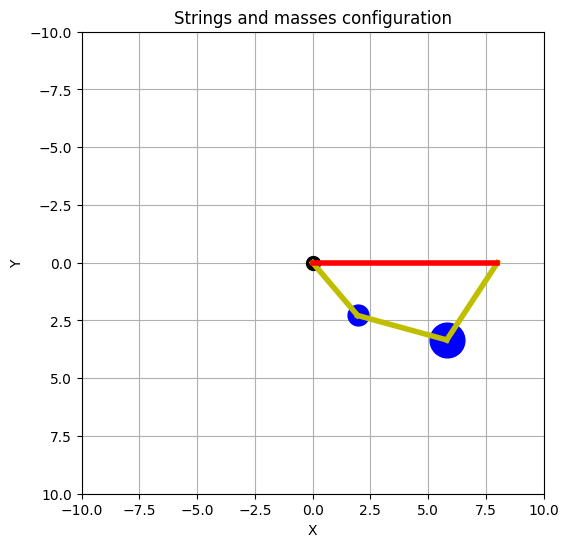

Number of iterations =  99
Solution:
x[ 0 ] =   0.7610026921018717
x[ 1 ] =   0.26495381028070264
x[ 2 ] =   0.8357058293571064
x[ 3 ] =   0.6487487207029421
x[ 4 ] =   0.9642611048972874
x[ 5 ] =   0.549177354575506
x[ 6 ] =   17.16020978460729
x[ 7 ] =   11.545279684327756
x[ 8 ] =   20.271578044639117


In [6]:
from numpy.linalg import solve
from numpy import array, take, zeros
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, clear_output

# 设置 matplotlib 内联模式
%matplotlib inline

n = 9
eps = 1e-6

deriv = zeros((n, n), float)
f = zeros((n), float)
x = array([0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 1.0, 1.0, 1.0])

# 初始化图形
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect("equal")
ax.grid(True)
ax.set_title("Strings and masses configuration")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.invert_yaxis()  # 反转y轴，使向下为正（模拟重力）

# 绘制固定点 (0,0)
ax.plot(0, 0, "ko", markersize=10)


def plotconfig():
    """使用 matplotlib 更新配置"""
    # 清除之前的绘图
    ax.clear()
    ax.set_xlim(-10, 10)
    ax.set_ylim(-10, 10)
    ax.set_aspect("equal")
    ax.grid(True)
    ax.set_title("Strings and masses configuration")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.invert_yaxis()  # 反转y轴，使向下为正（模拟重力）

    L1 = 3.0
    L2 = 4.0
    L3 = 4.0

    xa = L1 * x[3]  # L1*cos(th1)
    ya = L1 * x[0]  # L1*sin(th1)
    xb = xa + L2 * x[4]  # L1*cos(th1) + L2*cos(th2)
    yb = ya + L2 * x[1]  # L1*sin(th1) + L2*sen(th2)
    xc = xb + L3 * x[5]  # L1*cos(th1) + L2*cos(th2) + L3*cos(th3)
    yc = yb - L3 * x[2]  # L1*sin(th1) + L2*sen(th2) - L3*sin(th3)

    # 绘制点
    ax.plot(0, 0, "ko", markersize=10)  # 固定点
    ax.plot(xa, ya, "bo", markersize=15)  # ball1
    ax.plot(xb, yb, "bo", markersize=25)  # ball2

    # 绘制线段
    ax.plot([0, xa], [0, ya], "y-", linewidth=4)  # line1
    ax.plot([xa, xb], [ya, yb], "y-", linewidth=4)  # line2
    ax.plot([xb, xc], [yb, yc], "y-", linewidth=4)  # line3
    ax.plot([0, xc], [0, yc], "r-", linewidth=4)  # topline

    # 更新显示
    clear_output(wait=True)
    display(fig)
    plt.pause(0.1)  # 短暂暂停以显示更新


def F(x, f):
    """Define origin function"""
    f[0] = 3 * x[3] + 4 * x[4] + 4 * x[5] - 8.0
    f[1] = 3 * x[0] + 4 * x[1] - 4 * x[2]
    f[2] = x[6] * x[0] - x[7] * x[1] - 10.0
    f[3] = x[6] * x[3] - x[7] * x[4]
    f[4] = x[7] * x[1] + x[8] * x[2] - 20.0
    f[5] = x[7] * x[4] - x[8] * x[5]
    f[6] = pow(x[0], 2) + pow(x[3], 2) - 1.0
    f[7] = pow(x[1], 2) + pow(x[4], 2) - 1.0
    f[8] = pow(x[2], 2) + pow(x[5], 2) - 1.0


def dFi_dXj(x, deriv, n):
    """Define derivative function"""
    h = 1e-4
    for j in range(0, n):
        temp = x[j]
        x[j] = x[j] + h / 2.0
        F(x, f)
        for i in range(0, n):
            deriv[i, j] = f[i]
        x[j] = temp

    for j in range(0, n):
        temp = x[j]
        x[j] = x[j] - h / 2.0
        F(x, f)
        for i in range(0, n):
            deriv[i, j] = (deriv[i, j] - f[i]) / h
        x[j] = temp


for it in range(1, 100):
    F(x, f)
    dFi_dXj(x, deriv, n)
    B = array([[-f[0]], [-f[1]], [-f[2]], [-f[3]], [-f[4]], [-f[5]], [-f[6]], [-f[7]], [-f[8]]])
    sol = solve(deriv, B)
    # 修复：取第一列并展平为一维数组
    dx = sol[:, 0]
    for i in range(0, n):
        x[i] = x[i] + dx[i]
    plotconfig()
    errX = errF = errXi = 0.0

    for i in range(0, n):
        if x[i] != 0.0:
            errXi = abs(dx[i] / x[i])
        else:
            errXi = abs(dx[i])
        if errXi > errX:
            errX = errXi
        if abs(f[i]) > errF:
            errF = abs(f[i])
        if (errX <= eps) and (errF <= eps):
            break


print("Number of iterations = ", it)
print("Solution:")

for i in range(0, n):
    print("x[", i, "] =  ", x[i])